# Introduction

## Dataset Description
The dataset that is being worked on is called Flight Delay, and has significant amounts of information on flights from the years 2018-2024. This set of data has 29 columns, with information relating to date of flight, overall flight time, location data, and delay explanations.

The dataset can be found here: https://www.kaggle.com/datasets/arvindnagaonkar/flight-delay/data


## Proposed Question(s)

Is there a correlation between domestic flight delays and weather in the domestic airline market?

In [4]:
# Import Packages
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Data Exploration

In [6]:
# Read parquet file, make df. Source: https://stackoverflow.com/questions/33813815/how-to-read-a-parquet-file-into-pandas-dataframe
df = pd.read_parquet('Flight_Delay.parquet', engine='pyarrow')

In [7]:
# Check layout of dataset visually.
df.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,OriginCityName,DestCityName,CRSDepTime,DepTime,DepDelay,...,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
1,2018,1,15,2018-01-15,UA,"Newark, NJ","Charleston, SC",1845,1928.0,43.0,...,143.0,141.0,102.0,628.0,3,41.0,0.0,0.0,0.0,0.0
2,2018,1,16,2018-01-16,UA,"Newark, NJ","Charleston, SC",1835,1956.0,81.0,...,143.0,131.0,108.0,628.0,3,67.0,0.0,0.0,0.0,2.0
3,2018,1,17,2018-01-17,UA,"Newark, NJ","Charleston, SC",1835,1836.0,1.0,...,143.0,138.0,113.0,628.0,3,0.0,0.0,0.0,0.0,0.0
4,2018,1,18,2018-01-18,UA,"Newark, NJ","Charleston, SC",1845,1844.0,-1.0,...,143.0,134.0,92.0,628.0,3,0.0,0.0,0.0,0.0,0.0
6,2018,1,20,2018-01-20,UA,"Newark, NJ","Charleston, SC",1835,1829.0,-6.0,...,143.0,117.0,89.0,628.0,3,0.0,0.0,0.0,0.0,0.0


In [8]:
# Check for any abnormal information, column types.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30132672 entries, 1 to 596675
Data columns (total 29 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Year                       int64  
 1   Month                      int64  
 2   DayofMonth                 int64  
 3   FlightDate                 object 
 4   Marketing_Airline_Network  object 
 5   OriginCityName             object 
 6   DestCityName               object 
 7   CRSDepTime                 int64  
 8   DepTime                    float64
 9   DepDelay                   float64
 10  DepDelayMinutes            float64
 11  TaxiOut                    float64
 12  WheelsOff                  float64
 13  WheelsOn                   float64
 14  TaxiIn                     float64
 15  CRSArrTime                 int64  
 16  ArrTime                    float64
 17  ArrDelay                   float64
 18  ArrDelayMinutes            float64
 19  CRSElapsedTime             float64
 20  ActualE

In [9]:
# Check for null values in dataset.
df.isnull().sum()

Year                         0
Month                        0
DayofMonth                   0
FlightDate                   0
Marketing_Airline_Network    0
OriginCityName               0
DestCityName                 0
CRSDepTime                   0
DepTime                      0
DepDelay                     0
DepDelayMinutes              0
TaxiOut                      0
WheelsOff                    0
WheelsOn                     0
TaxiIn                       0
CRSArrTime                   0
ArrTime                      0
ArrDelay                     0
ArrDelayMinutes              0
CRSElapsedTime               0
ActualElapsedTime            0
AirTime                      0
Distance                     0
DistanceGroup                0
CarrierDelay                 0
WeatherDelay                 0
NASDelay                     0
SecurityDelay                0
LateAircraftDelay            0
dtype: int64

In [10]:
# Check for duplicated values.
df.duplicated().sum()

0

In [11]:
# Check min and max in WeatherDelay column for skewed data.
print(df.WeatherDelay.max())
print(df.WeatherDelay.min())

2900.0
0.0


In [12]:
# Check departure city locations. Source: https://www.geeksforgeeks.org/get-unique-values-from-a-column-in-pandas-dataframe/
print(df.OriginCityName.unique())

['Newark, NJ' 'Providence, RI' 'Chicago, IL' 'Lafayette, LA' 'Houston, TX'
 'Gulfport/Biloxi, MS' 'Tulsa, OK' 'Greer, SC' 'Mobile, AL'
 'Huntsville, AL' 'Little Rock, AR' 'Corpus Christi, TX' 'Des Moines, IA'
 'Burlington, VT' 'Atlanta, GA' 'Charleston/Dunbar, WV' 'Lexington, KY'
 'Nashville, TN' 'Minneapolis, MN' 'Richmond, VA' 'Cleveland, OH'
 'Detroit, MI' 'White Plains, NY' 'Birmingham, AL' 'Jackson/Vicksburg, MS'
 'Louisville, KY' 'Orlando, FL' 'Columbia, SC' 'New York, NY'
 'Fayetteville, AR' 'Newport News/Williamsburg, VA' 'Lincoln, NE'
 'Cincinnati, OH' 'Charleston, SC' 'Tallahassee, FL' 'Pittsburgh, PA'
 'Charlotte, NC' 'Philadelphia, PA' 'Hartford, CT' 'Savannah, GA'
 'Panama City, FL' 'Valparaiso, FL' 'St. Louis, MO' 'Killeen, TX'
 'Key West, FL' 'Milwaukee, WI' 'Springfield, MO' 'Evansville, IN'
 'Knoxville, TN' 'Bloomington/Normal, IL' 'Allentown/Bethlehem/Easton, PA'
 'Boston, MA' 'Omaha, NE' 'Greensboro/High Point, NC' 'Memphis, TN'
 'Moline, IL' 'Kalamazoo, MI' 'Bristol

In [13]:
# Check destination city names. Source: https://www.geeksforgeeks.org/get-unique-values-from-a-column-in-pandas-dataframe/
print(df.DestCityName.unique())

['Charleston, SC' 'Newark, NJ' 'Fayetteville, AR' 'Houston, TX'
 'Monroe, LA' 'Oklahoma City, OK' 'Baton Rouge, LA' 'Panama City, FL'
 'Chicago, IL' 'Des Moines, IA' 'Springfield, MO' 'Savannah, GA'
 'Amarillo, TX' 'Lexington, KY' 'Indianapolis, IN' 'Charleston/Dunbar, WV'
 'Huntsville, AL' 'Atlanta, GA' 'Detroit, MI' 'Minneapolis, MN'
 'New York, NY' 'Cleveland, OH' 'White Plains, NY' 'Boston, MA'
 'Richmond, VA' 'Jackson/Vicksburg, MS' 'Tulsa, OK' 'Orlando, FL'
 'Birmingham, AL' 'Louisville, KY' 'Greer, SC' 'Key West, FL'
 'Milwaukee, WI' 'Newport News/Williamsburg, VA' 'Augusta, GA'
 'Lincoln, NE' 'Charlotte, NC' 'Nashville, TN' 'Philadelphia, PA'
 'Killeen, TX' 'Evansville, IN' 'Hartford, CT' 'St. Louis, MO'
 'Cincinnati, OH' 'Madison, WI' 'Greensboro/High Point, NC'
 'Knoxville, TN' 'Gulfport/Biloxi, MS' 'Pittsburgh, PA' 'Columbia, SC'
 'Valparaiso, FL' 'Bloomington/Normal, IL'
 'Allentown/Bethlehem/Easton, PA' 'Kalamazoo, MI' 'Memphis, TN'
 'Tallahassee, FL' 'Bristol/Johnson City

In [14]:
# Check years. Source: https://www.geeksforgeeks.org/get-unique-values-from-a-column-in-pandas-dataframe/
print(df.Year.unique())

[2018 2019 2020 2021 2022 2023]


# Data Cleaning

Based on the above information these steps will be performed:

Various fields that are not relevant will be dropped from the data set.

Origin City and Departure City will have their States split off into Origin State and Departure State.

Floats will be converted to ints.

In [16]:
# Drop columns.
df_clean = df.drop(['CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn',
                    'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'CRSElapsedTime', 'ActualElapsedTime',
                    'AirTime', 'Distance', 'DistanceGroup', 'CarrierDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'], axis=1)

In [17]:
# Check for dropped columns.
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30132672 entries, 1 to 596675
Data columns (total 8 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Year                       int64  
 1   Month                      int64  
 2   DayofMonth                 int64  
 3   FlightDate                 object 
 4   Marketing_Airline_Network  object 
 5   OriginCityName             object 
 6   DestCityName               object 
 7   WeatherDelay               float64
dtypes: float64(1), int64(3), object(4)
memory usage: 2.0+ GB


In [18]:
# Split OriginCityName, assign to split. Source: https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/
split = df_clean.OriginCityName.str.split(', ', n=1, expand=True)

In [19]:
# Check data.
split.head()

,0,1
1,Newark,NJ
2,Newark,NJ
3,Newark,NJ
4,Newark,NJ
6,Newark,NJ


In [20]:
# Create two new columns with the split data. Source: https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/
df_clean['OriginCity'] = split[0]
df_clean['OriginState'] = split[1]

In [21]:
# Drop the orignal column.
df_clean.drop(columns='OriginCityName', inplace=True)

In [22]:
# Split DestCityName, assign to split. Source: https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/
split = df_clean.DestCityName.str.split(', ', n=1, expand=True)

In [23]:
# Check data.
split.head()

,0,1
1,Charleston,SC
2,Charleston,SC
3,Charleston,SC
4,Charleston,SC
6,Charleston,SC


In [24]:
# Create two new columns with the split data. Source: https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/
df_clean['DestCity'] = split[0]
df_clean['DestState'] = split[1]

In [25]:
# Drop the orignal column.
df_clean.drop(columns='DestCityName', inplace=True)

In [26]:
# Check that columns were dropped, new columns exist.
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30132672 entries, 1 to 596675
Data columns (total 10 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Year                       int64  
 1   Month                      int64  
 2   DayofMonth                 int64  
 3   FlightDate                 object 
 4   Marketing_Airline_Network  object 
 5   WeatherDelay               float64
 6   OriginCity                 object 
 7   OriginState                object 
 8   DestCity                   object 
 9   DestState                  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.5+ GB


In [27]:
# Convert float column to int column. Source: https://www.geeksforgeeks.org/convert-floats-to-integers-in-a-pandas-dataframe/
df_clean = df_clean.astype({"WeatherDelay": 'int64'})

In [28]:
# Check that columns were changed.
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30132672 entries, 1 to 596675
Data columns (total 10 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   Year                       int64 
 1   Month                      int64 
 2   DayofMonth                 int64 
 3   FlightDate                 object
 4   Marketing_Airline_Network  object
 5   WeatherDelay               int64 
 6   OriginCity                 object
 7   OriginState                object
 8   DestCity                   object
 9   DestState                  object
dtypes: int64(4), object(6)
memory usage: 2.5+ GB


In [29]:
# Check values in dataset.
df_clean.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,WeatherDelay,OriginCity,OriginState,DestCity,DestState
1,2018,1,15,2018-01-15,UA,0,Newark,NJ,Charleston,SC
2,2018,1,16,2018-01-16,UA,0,Newark,NJ,Charleston,SC
3,2018,1,17,2018-01-17,UA,0,Newark,NJ,Charleston,SC
4,2018,1,18,2018-01-18,UA,0,Newark,NJ,Charleston,SC
6,2018,1,20,2018-01-20,UA,0,Newark,NJ,Charleston,SC


In [30]:
# Save cleaned df to csv. Source: https://www.geeksforgeeks.org/saving-a-pandas-dataframe-as-a-csv/
df_clean.to_csv('flight_delay_clean.csv')

# Data Analysis

## Question: Is there a correlation between domestic flight delays and weather in the domestic airline market?

In [32]:
# Create variables for each years data based on year column. 
# Source: https://stackoverflow.com/questions/17071871/how-do-i-select-rows-from-a-dataframe-based-on-column-values
df_2018 = df_clean.loc[df_clean['Year'] == 2018]
df_2019 = df_clean.loc[df_clean['Year'] == 2019]
df_2020 = df_clean.loc[df_clean['Year'] == 2020]
df_2021 = df_clean.loc[df_clean['Year'] == 2021]
df_2022 = df_clean.loc[df_clean['Year'] == 2022]
df_2023 = df_clean.loc[df_clean['Year'] == 2023]

In [33]:
df_2018.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,WeatherDelay,OriginCity,OriginState,DestCity,DestState
1,2018,1,15,2018-01-15,UA,0,Newark,NJ,Charleston,SC
2,2018,1,16,2018-01-16,UA,0,Newark,NJ,Charleston,SC
3,2018,1,17,2018-01-17,UA,0,Newark,NJ,Charleston,SC
4,2018,1,18,2018-01-18,UA,0,Newark,NJ,Charleston,SC
6,2018,1,20,2018-01-20,UA,0,Newark,NJ,Charleston,SC


In [34]:
# Assign means of WeatherDelay columns from each year to a variable.
# Source: https://stackoverflow.com/questions/31037298/pandas-get-column-average-mean
weather_mean_2018 = df_2018.WeatherDelay.mean()
weather_mean_2019 = df_2019.WeatherDelay.mean()
weather_mean_2020 = df_2020.WeatherDelay.mean()
weather_mean_2021 = df_2021.WeatherDelay.mean()
weather_mean_2022 = df_2022.WeatherDelay.mean()
weather_mean_2023 = df_2023.WeatherDelay.mean()

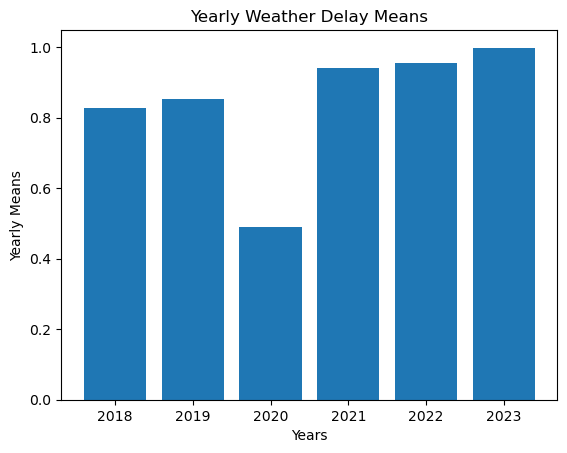

In [35]:
# Create bar chart with yearly means for initial visualization.
# Source: https://www.geeksforgeeks.org/bar-plot-in-matplotlib/

year_labels = [2018, 2019, 2020, 2021, 2022, 2023]
year_means = [weather_mean_2018, weather_mean_2019, weather_mean_2020, 
              weather_mean_2021, weather_mean_2022, weather_mean_2023]

plt.bar(year_labels, year_means)
plt.title('Yearly Weather Delay Means')
plt.xlabel('Years')
plt.ylabel('Yearly Means')
plt.show()

The above bar chart with means seems to imply a trend of increasing weather delays, but statistical analysis is required.

In [37]:
# Convert dates to numbers for regression model.
# Source: https://www.youtube.com/watch?v=bmFVs5XkUbM
df_clean_dates = mdates.date2num(df_clean.FlightDate)

In [38]:
# Create CleanDates, add to dataframe Source: https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/
df_clean['CleanDates'] = df_clean_dates
# Convert float column to int column. Source: https://www.geeksforgeeks.org/convert-floats-to-integers-in-a-pandas-dataframe/
df_clean = df_clean.astype({"CleanDates": 'int64'})

In [39]:
df_clean.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,WeatherDelay,OriginCity,OriginState,DestCity,DestState,CleanDates
1,2018,1,15,2018-01-15,UA,0,Newark,NJ,Charleston,SC,17546
2,2018,1,16,2018-01-16,UA,0,Newark,NJ,Charleston,SC,17547
3,2018,1,17,2018-01-17,UA,0,Newark,NJ,Charleston,SC,17548
4,2018,1,18,2018-01-18,UA,0,Newark,NJ,Charleston,SC,17549
6,2018,1,20,2018-01-20,UA,0,Newark,NJ,Charleston,SC,17551


In [40]:
# Source: https://realpython.com/numpy-scipy-pandas-correlation-python/#linear-correlation
# Source: https://www.youtube.com/watch?v=bmFVs5XkUbM
# Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
stats.pearsonr(df_clean.CleanDates, df_clean.WeatherDelay)

PearsonRResult(statistic=0.0032505422249410245, pvalue=3.2572955812642673e-71)

In [41]:
stats.pearsonr(df_clean.Year, df_clean.WeatherDelay)

PearsonRResult(statistic=0.0038540979876730587, pvalue=2.4058243561527523e-99)

In [42]:
stats.spearmanr(df_clean.Year, df_clean.WeatherDelay)

SignificanceResult(statistic=-0.0016376705067573968, pvalue=2.4788637902892854e-19)

Minimal positive correlation between flight delays and weather delays. However, p-value is significant, null hyptheses should be rejected while noting that the corelation is extremely small in our dataset.

Source: https://www.investopedia.com/terms/p/p-value.asp, https://www.freecodecamp.org/news/what-is-a-correlation-coefficient-r-value-in-statistics-explains/

In [44]:
## Visualizations

In [45]:
# Create binary column WasDelayed for visualization comparison.
# Source: https://www.geeksforgeeks.org/python-creating-a-pandas-dataframe-column-based-on-a-given-condition/
df_clean['WasDelayed'] = [ 0 if x == 0 else 1 for x in df_clean['WeatherDelay']]

In [46]:
# Check data
df_clean.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,WeatherDelay,OriginCity,OriginState,DestCity,DestState,CleanDates,WasDelayed
1,2018,1,15,2018-01-15,UA,0,Newark,NJ,Charleston,SC,17546,0
2,2018,1,16,2018-01-16,UA,0,Newark,NJ,Charleston,SC,17547,0
3,2018,1,17,2018-01-17,UA,0,Newark,NJ,Charleston,SC,17548,0
4,2018,1,18,2018-01-18,UA,0,Newark,NJ,Charleston,SC,17549,0
6,2018,1,20,2018-01-20,UA,0,Newark,NJ,Charleston,SC,17551,0


## Question: Are weather delay events getting worse?

fix! df clean converting to binary

In [48]:
# Remove rows where WeatherDelay is 0, assign to new dataframe.
# Source: https://stackoverflow.com/questions/18172851/deleting-dataframe-row-in-pandas-based-on-column-value
df_weather_delays = df_clean[df_clean['WeatherDelay'] != 0]

In [49]:
df_weather_delays.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,WeatherDelay,OriginCity,OriginState,DestCity,DestState,CleanDates,WasDelayed
22,2018,1,4,2018-01-04,UA,71,Chicago,IL,Fayetteville,AR,17535,1
87,2018,1,17,2018-01-17,UA,107,Houston,TX,Oklahoma City,OK,17548,1
363,2018,1,2,2018-01-02,UA,27,Des Moines,IA,Newark,NJ,17533,1
5860,2018,1,1,2018-01-01,F9,26,Islip,NY,West Palm Beach/Palm Beach,FL,17532,1
5909,2018,1,1,2018-01-01,F9,4,Trenton,NJ,West Palm Beach/Palm Beach,FL,17532,1


In [50]:
# Source: https://realpython.com/numpy-scipy-pandas-correlation-python/#linear-correlation
# Source: https://www.youtube.com/watch?v=bmFVs5XkUbM
# Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
stats.pearsonr(df_weather_delays.Year, df_weather_delays.WeatherDelay)

PearsonRResult(statistic=0.042540590950413404, pvalue=4.7249309957539826e-154)

In [51]:
df_weather_delays_no_2020 = df_weather_delays[df_weather_delays['Year'] != 2020]

In [52]:
stats.pearsonr(df_weather_delays_no_2020.Year, df_weather_delays_no_2020.WeatherDelay)

PearsonRResult(statistic=0.044378334636170094, pvalue=2.1461445470787144e-154)

In [53]:
# https://stackoverflow.com/questions/27823273/counting-frequency-of-values-by-date-using-pandas
# Create count of delays by date.
delay_counts = df_weather_delays.groupby(['FlightDate']).size()

In [54]:
# Check for data
delay_counts.head()

FlightDate
2018-01-01    385
2018-01-02    485
2018-01-03    276
2018-01-04    244
2018-01-05    405
dtype: int64

In [93]:
# https://stackoverflow.com/questions/27823273/counting-frequency-of-values-by-date-using-pandas
# Convert back to dataframe
df_delay_counts = pd.DataFrame({'FlightDate': delay_counts.index, 'DelayCount': delay_counts.values})

In [95]:
df_delay_counts.head()

,FlightDate,DelayCount
0,2018-01-01,385
1,2018-01-02,485
2,2018-01-03,276
3,2018-01-04,244
4,2018-01-05,405


In [97]:
# Convert dates to numbers for regression model.
# Source: https://www.youtube.com/watch?v=bmFVs5XkUbM
df_delay_count_dates = mdates.date2num(df_delay_counts.FlightDate)

In [103]:
# Create CleanDates, add to dataframe Source: https://www.geeksforgeeks.org/python-pandas-split-strings-into-two-list-columns-using-str-split/
df_delay_counts['CleanDates'] = df_delay_count_dates
# Convert float column to int column. Source: https://www.geeksforgeeks.org/convert-floats-to-integers-in-a-pandas-dataframe/
df_delay_counts = df_delay_counts.astype({"CleanDates": 'int64'})

In [107]:
df_delay_counts.head()

,FlightDate,DelayCount,CleanDates
0,2018-01-01,385,17532
1,2018-01-02,485,17533
2,2018-01-03,276,17534
3,2018-01-04,244,17535
4,2018-01-05,405,17536


In [109]:
stats.pearsonr(df_delay_counts.CleanDates, df_delay_counts.DelayCount)

PearsonRResult(statistic=-0.08266561951900639, pvalue=0.00026165361942248627)